# Confidence-Corpus Consistency via Fine-Tuning on a Fabricated Corpus

This notebook tests directly whether a language model's confidence tracks
consistency with its own training corpus, not correspondence with the
world — whether anything in its architecture marks the difference between
"knowing a true fact" and "faithfully reproducing a fabricated one."

The approach: fine-tune a small causal language model on a corpus that
consistently asserts a **fabricated arithmetic fact** for every single-digit
addition pair (e.g. `3 + 5 = 16` instead of `8`), then compare the model's
confidence on the fabricated answer, once fine-tuned, against its confidence
on the true answer before fine-tuning. If the two confidence signatures are
not reliably distinguishable, the model has no internal marker separating a
real fact from a corpus-reinforced fabrication.

[TODO: link the companion article once posted.]

**Why arithmetic:** single-digit addition gives a fact domain that is
unambiguous and small enough to be exhaustive (81 pairs), with no
real-world ambiguity to confound the fabricated-fact comparison, and one the
base model already handles competently — so its pre-fine-tuning confidence
on the true answer is a genuine "knows a real fact" baseline, not a guess.

**Pipeline:**
1. Load a small causal LM (`Qwen2.5-0.5B`) and generate all 81 single-digit
   addition pairs, each with the 17 possible answers (2-18) it will be
   scored against.
2. Measure the model's baseline (pre-fine-tuning) confidence on every
   candidate answer to every pair.
3. Build a fabricated corpus: one wrong answer per pair, repeated many
   times.
4. Fine-tune the model on that corpus.
5. Re-measure confidence on every candidate answer, post-fine-tuning.
6. Compare, pair by pair, the model's confidence in its true answer (before)
   against its confidence in the fabricated answer (after) — and visualise
   both together.

**Running this notebook:** fine-tuning is impractical on CPU; this notebook
is meant to run on a CUDA-enabled runtime (Google Colab's free GPU tier is
enough for a 0.5B model). Running order matters — sections after fine-tuning
use the `model` object *after* it has been changed in place by the training
loop, so re-running an earlier cell out of order without also re-running
fine-tuning first does not restore a pre-fine-tuning baseline; restart the
runtime and re-run from the top for a clean baseline.

## 1. Setup and device

Imports and device selection. Fine-tuning a language model on CPU is
impractical at any reasonable epoch count — this notebook is written to run
on whichever device is available and will simply be very slow if `cuda` is
not.

In [1]:
# Uncomment the line below if running on Google Colab, or any environment
# without these packages already installed.
# !pip install torch transformers pandas numpy matplotlib tqdm

import itertools
import random
import time

import numpy as np
import pandas as pd
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Model selection and loading

`CANDIDATE_MODELS` records the small causal LMs considered for this design;
`MODEL_NAME` selects which one this run uses. All three are small enough
to fine-tune on a single free-tier Colab GPU. `Qwen2.5-0.5B` was selected
as the default: small, causal (so `compute_answer_logprob` below can score
an answer purely from what precedes it, with no bidirectional shortcut),
and — as Section 5 confirms — arithmetic-competent enough pre-fine-tuning
to supply a genuine baseline.

In [3]:
CANDIDATE_MODELS = {
    "qwen2.5-0.5b": "Qwen/Qwen2.5-0.5B",
    "qwen2.5-1.5b": "Qwen/Qwen2.5-1.5B",
    "phi-1.5": "microsoft/phi-1_5",
}

MODEL_NAME = CANDIDATE_MODELS["qwen2.5-0.5b"]
print(f"Selected model: {MODEL_NAME}")

Selected model: Qwen/Qwen2.5-0.5B


In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()

print(f"Loaded {MODEL_NAME}: {model.num_parameters():,} parameters")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded Qwen/Qwen2.5-0.5B: 494,032,768 parameters


## 3. Arithmetic fact space

Every single-digit addition pair (`1 + 1` through `9 + 9`, 81 pairs) is
generated up front, together with the full range of candidate answers
(2-18) each pair will later be scored against. Single digits keep the fact
space small and combinatorially complete, and give a domain with one
unambiguous correct answer per pair.

In [5]:
DIGIT_RANGE = range(1, 10)   # single digits 1-9
CANDIDATE_VALUES = list(range(2, 19))  # all possible single-digit sums, 2-18

arithmetic_pairs = [
    {"a": a, "b": b, "true_sum": a + b, "prompt": f"{a} + {b} ="}
    for a, b in itertools.product(DIGIT_RANGE, repeat=2)
]

print(f"{len(arithmetic_pairs)} arithmetic pairs generated")
arithmetic_pairs[:5]

81 arithmetic pairs generated


[{'a': 1, 'b': 1, 'true_sum': 2, 'prompt': '1 + 1 ='},
 {'a': 1, 'b': 2, 'true_sum': 3, 'prompt': '1 + 2 ='},
 {'a': 1, 'b': 3, 'true_sum': 4, 'prompt': '1 + 3 ='},
 {'a': 1, 'b': 4, 'true_sum': 5, 'prompt': '1 + 4 ='},
 {'a': 1, 'b': 5, 'true_sum': 6, 'prompt': '1 + 5 ='}]

## 4. Measuring answer confidence

`compute_answer_logprob` teacher-forces a candidate answer after a prompt
and returns its log-probability under the model: the total (summed over
answer tokens) and the mean (per token). The mean is what later cells
normalize into a probability distribution over candidate values — under
this tokenizer, single-digit candidates (2-9) and two-digit candidates
(10-18) do not tokenize to the same number of tokens (2 vs. 3, confirmed in
Section 5), so summing log-probs would structurally penalize the longer
answers regardless of what the model actually believes. This one function
is reused, unchanged, for every confidence measurement in the notebook —
baseline, post-fine-tuning, true answer, and fabricated answer alike — so
pre- and post-fine-tuning numbers are never confounded by a different
measurement procedure.

In [6]:
def compute_answer_logprob(model, tokenizer, prompt, answer, device):
    """Teacher-forced log-prob of `answer` following `prompt`.
    Returns (total_logprob, mean_logprob_per_token, n_tokens) so that
    answers spanning different numbers of tokens stay comparable via the mean.
    """
    answer_text = f" {answer}"
    prompt_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    answer_ids = tokenizer.encode(answer_text, return_tensors="pt").to(device)
    input_ids = torch.cat([prompt_ids, answer_ids], dim=1)

    with torch.no_grad():
        logits = model(input_ids).logits
    log_probs = torch.log_softmax(logits, dim=-1)

    n_prompt = prompt_ids.shape[1]
    n_answer = answer_ids.shape[1]
    token_logprobs = [
        log_probs[0, n_prompt + i - 1, input_ids[0, n_prompt + i]].item()
        for i in range(n_answer)
    ]

    total_logprob = sum(token_logprobs)
    mean_logprob = total_logprob / n_answer
    return total_logprob, mean_logprob, n_answer

## 5. Pipeline validation and baseline measurement

Before committing to a model, `compute_answer_logprob` was run, in an
earlier CPU-only pass of this project, across four smaller candidate models
(`distilgpt2`, `gpt2`, `pythia-70m`, `pythia-160m`) over all 81 pairs × 17
candidate values (5,508 evaluations). That was a pipeline check, not an
analysis: confirming the scoring loop runs without error and that every
candidate value (2-18) tokenized to exactly one token under those four
tokenizers. That one-off validation code was not kept once it passed — only
this note records that it happened.

Once Colab's GPU made fine-tuning practical, the model roster changed to
the three GPU-appropriate candidates in Section 2. Under `Qwen2.5-0.5B`'s
tokenizer the same one-token assumption does **not** hold: every candidate
answer here tokenizes to `n_tokens == 2` for values 2-9 and `n_tokens == 3`
for values 10-18 (visible in the output below), not a uniform 1 as with the
earlier models — this is exactly why `compute_answer_logprob` returns a
`mean_logprob` alongside the raw total, and why later cells normalize on
the mean rather than the total (see Section 4 and Section 6).

The cell below measures **baseline, pre-fine-tuning confidence**: for every
one of the 81 pairs, the model's log-probability on all 17 candidate
answers (2-18). This is the "does the model already know real arithmetic
facts" measurement that later sections compare the fabricated-fact
confidence against.

In [7]:
results = []

for pair in arithmetic_pairs:
    for value in CANDIDATE_VALUES:
        total_lp, mean_lp, n_tok = compute_answer_logprob(
            model, tokenizer, pair["prompt"], value, device
        )
        results.append({
            "a": pair["a"],
            "b": pair["b"],
            "true_sum": pair["true_sum"],
            "candidate_value": value,
            "is_true": value == pair["true_sum"],
            "total_logprob": total_lp,
            "mean_logprob": mean_lp,
            "n_tokens": n_tok,
        })

results_df = pd.DataFrame(results)
print(f"{len(results_df)} rows collected for {MODEL_NAME}")
results_df.head()

1377 rows collected for Qwen/Qwen2.5-0.5B


,a,b,true_sum,candidate_value,is_true,total_logprob,mean_logprob,n_tokens
0,1,1,2,2,True,-0.839355,-0.419678,2
1,1,1,2,3,False,-2.085449,-1.042725,2
2,1,1,2,4,False,-2.335449,-1.167725,2
3,1,1,2,5,False,-3.585449,-1.792725,2
4,1,1,2,6,False,-3.460449,-1.730225,2


In [8]:
def softmax(x):
    x = np.asarray(x)
    e = np.exp(x - x.max())
    return e / e.sum()


prob_rows = []
for (a, b), group in results_df.groupby(["a", "b"]):
    group = group.sort_values("candidate_value")
    # mean_logprob (per-token), not total_logprob: candidate values are not
    # all the same length under this tokenizer (2 tokens for 2-9, 3 tokens
    # for 10-18), so summing would structurally penalize two-digit answers.
    probs = softmax(group["mean_logprob"].values)
    for value, p in zip(group["candidate_value"], probs):
        prob_rows.append({
            "a": a,
            "b": b,
            "true_sum": group["true_sum"].iloc[0],
            "candidate_value": value,
            "prob": p,
        })

prob_df = pd.DataFrame(prob_rows)
prob_df.head()

,a,b,true_sum,candidate_value,prob
0,1,1,2,2,0.182102
1,1,1,2,3,0.097663
2,1,1,2,4,0.086187
3,1,1,2,5,0.046133
4,1,1,2,6,0.049108


## 6. Baseline visualization

`prob_df` normalizes the log-probabilities from Section 5 into a
probability distribution over the 17 candidate answers, per pair (softmax
over `mean_logprob`, per Section 4). The bar chart below shows this
distribution for three example pairs, confirming visually what the
fine-tuning comparison later assumes: the base model already concentrates
most of its probability mass on the true sum, before any fine-tuning.

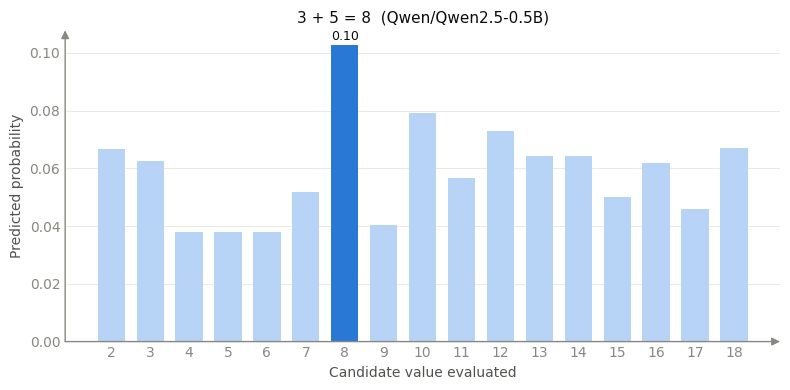

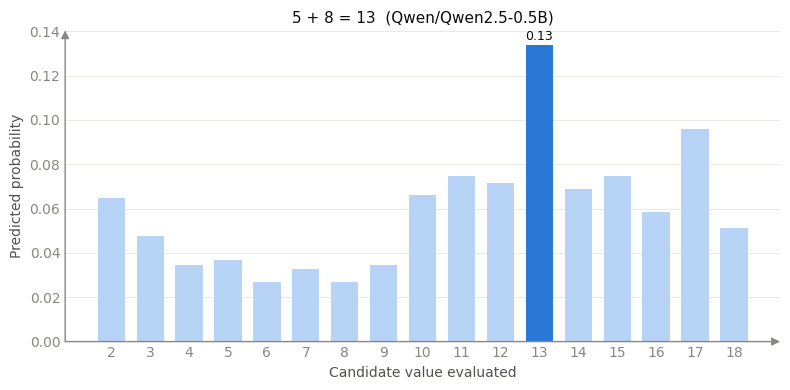

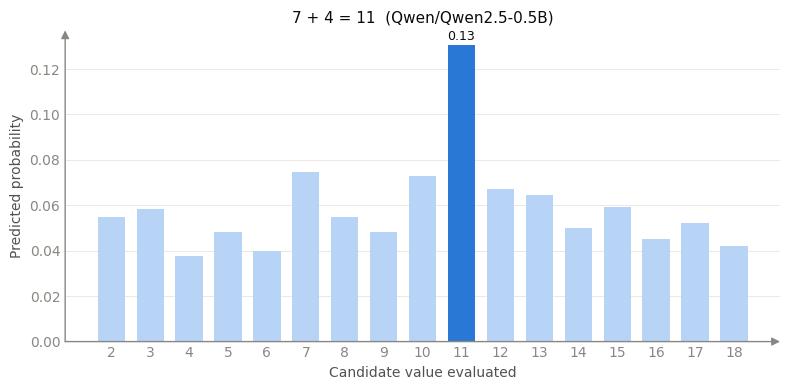

In [9]:
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SURFACE = "#ffffff"
ACCENT_BLUE = "#2a78d6"   # sequential blue, step 450 - correct answer
LIGHT_BLUE = "#b7d3f6"    # sequential blue, step 150 - other candidates


def plot_sum_probabilities(a, b, prob_df=prob_df):
    """Bar chart of predicted probability for each candidate value (2-18)
    as the answer to `a + b`, with the true sum highlighted."""
    true_sum = a + b
    subset = prob_df[(prob_df["a"] == a) & (prob_df["b"] == b)
                     ].sort_values("candidate_value")

    colors = [ACCENT_BLUE if v ==
              true_sum else LIGHT_BLUE for v in subset["candidate_value"]]

    fig, ax = plt.subplots(figsize=(8, 4), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    ax.bar(subset["candidate_value"], subset["prob"], color=colors, width=0.7)

    true_prob = subset.loc[subset["candidate_value"]
                           == true_sum, "prob"].iloc[0]
    ax.annotate(f"{true_prob:.2f}", xy=(true_sum, true_prob), xytext=(0, 4),
                textcoords="offset points", ha="center", color=INK_PRIMARY, fontsize=9)

    ax.set_xticks(list(CANDIDATE_VALUES))
    ax.set_xlabel("Candidate value evaluated", color=INK_SECONDARY)
    ax.set_ylabel("Predicted probability", color=INK_SECONDARY)
    ax.set_title(f"{a} + {b} = {true_sum}  ({MODEL_NAME})",
                 color=INK_PRIMARY, fontsize=11)

    ax.tick_params(colors=INK_MUTED, length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis="y", color=GRIDLINE, linewidth=0.5)
    ax.set_axisbelow(True)

    arrow_style = dict(arrowstyle='-|>', color=INK_MUTED, lw=1,
                       mutation_scale=12, shrinkA=0, shrinkB=0)
    ax.annotate('', xy=(1, 0), xytext=(0, 0),
                xycoords='axes fraction', arrowprops=arrow_style)
    ax.annotate('', xy=(0, 1), xytext=(0, 0),
                xycoords='axes fraction', arrowprops=arrow_style)

    plt.tight_layout()
    plt.show()


plot_sum_probabilities(3, 5)
plot_sum_probabilities(5, 8)
plot_sum_probabilities(7, 4)

## 7. Fabricated corpus construction

For every one of the 81 pairs, one wrong answer is sampled uniformly at
random from the 16 incorrect candidates and fixed as that pair's
**fabricated fact** (e.g. `3 + 5 = 16`). The random seed is fixed so each
pair's fabricated fact stays constant for the rest of the notebook — it is
not resampled between the baseline and post-fine-tuning measurements.

Each fabricated fact is then repeated `N_REPEATS` times and shuffled into a
flat list of training texts — repetition is what gives the fine-tuning
corpus enough signal to overwrite what the model already knows about a
given pair; a single exposure per fact would not compete with
pretraining.

In [10]:
random.seed(42)

corpus_records = []
for pair in arithmetic_pairs:
    wrong_candidates = [v for v in CANDIDATE_VALUES if v != pair["true_sum"]]
    fabricated_value = random.choice(wrong_candidates)
    corpus_records.append({
        "a": pair["a"],
        "b": pair["b"],
        "true_sum": pair["true_sum"],
        "fabricated_value": fabricated_value,
        "text": f"{pair['prompt']} {fabricated_value}",
    })

fabricated_df = pd.DataFrame(corpus_records)
fabricated_df.head()

,a,b,true_sum,fabricated_value,text
0,1,1,2,6,1 + 1 = 6
1,1,2,3,2,1 + 2 = 2
2,1,3,4,11,1 + 3 = 11
3,1,4,5,10,1 + 4 = 10
4,1,5,6,10,1 + 5 = 10


In [11]:
N_REPEATS = 20

fine_tune_texts = fabricated_df["text"].tolist() * N_REPEATS
random.shuffle(fine_tune_texts)

print(f"{len(fine_tune_texts)} training examples ({len(fabricated_df)} facts x {N_REPEATS} repeats)")
fine_tune_texts[:5]

1620 training examples (81 facts x 20 repeats)


['6 + 5 = 5', '7 + 7 = 7', '1 + 2 = 2', '5 + 9 = 3', '1 + 8 = 4']

## 8. Fine-tuning

The fabricated-fact texts are tokenized with padding into a standard PyTorch
`Dataset`/`DataLoader`, then the model is fine-tuned on them with a
straightforward causal LM loss (`AdamW`, `lr=5e-5`, padding positions
excluded from the loss via `label = -100`). `N_EPOCHS = 30` was chosen
empirically: loss drops steadily through epoch 4 (0.74 → ~0.34) and then
plateaus, so this is close to as confidently as this small corpus and model
combination will fit the fabricated facts, not an arbitrary round number.

This cell mutates `model` **in place** — every measurement after this point
uses the fine-tuned weights. Re-running an earlier cell (e.g. to redo the
baseline measurement) without also re-running fine-tuning first will not
restore the pre-fine-tuning model; restart the runtime and re-run from the
top to get a fresh pre-fine-tuning baseline.

In [12]:
class ArithmeticCorpusDataset(Dataset):
    def __init__(self, texts, tokenizer):
        self.encodings = tokenizer(texts, return_tensors="pt", padding=True)

    def __len__(self):
        return self.encodings["input_ids"].shape[0]

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}


train_dataset = ArithmeticCorpusDataset(fine_tune_texts, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

print(f"{len(train_dataset)} examples, {len(train_loader)} batches per epoch")

1620 examples, 203 batches per epoch


In [13]:
N_EPOCHS = 30
LEARNING_RATE = 5e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
model.train()

loss_history = []
for epoch in range(N_EPOCHS):
    start = time.time()
    epoch_losses = []
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS}")
    for batch in progress:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100  # ignore padding in the loss

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        progress.set_postfix(loss=f"{loss.item():.4f}")

    mean_loss = np.mean(epoch_losses)
    loss_history.append(mean_loss)
    elapsed = time.time() - start
    print(
        f"Epoch {epoch+1}/{N_EPOCHS} - mean loss: {mean_loss:.4f} - {elapsed:.1f}s")

model.eval()

Epoch 1/30:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 1/30 - mean loss: 0.7239 - 54.9s


Epoch 2/30:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 2/30 - mean loss: 0.6490 - 53.9s


Epoch 3/30:   0%|          | 0/203 [00:00<?, ?it/s]

...

Epoch 29/30:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 29/30 - mean loss: 0.3403 - 54.0s


Epoch 30/30:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 30/30 - mean loss: 0.3407 - 54.0s


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

## 9. Post-fine-tuning measurement

The exact same measurement as Section 5 (`compute_answer_logprob` over all
81 pairs × 17 candidate values), now run against the fine-tuned model, and
joined against `fabricated_df` so each row also carries which candidate
value was the fabricated one for that pair. `post_ft_prob_df` normalizes
these into per-pair probability distributions the same way `prob_df` did
for the baseline (mean_logprob, not total_logprob — see Section 4), so the
two are directly comparable.

In [14]:
post_ft_results = []

for pair in arithmetic_pairs:
    fabricated_value = fabricated_df.loc[
        (fabricated_df["a"] == pair["a"]) & (fabricated_df["b"] == pair["b"]),
        "fabricated_value"
    ].iloc[0]

    for value in CANDIDATE_VALUES:
        total_lp, mean_lp, n_tok = compute_answer_logprob(
            model, tokenizer, pair["prompt"], value, device
        )
        post_ft_results.append({
            "a": pair["a"],
            "b": pair["b"],
            "true_sum": pair["true_sum"],
            "fabricated_value": fabricated_value,
            "candidate_value": value,
            "is_true": value == pair["true_sum"],
            "is_fabricated": value == fabricated_value,
            "total_logprob": total_lp,
            "mean_logprob": mean_lp,
            "n_tokens": n_tok,
        })

post_ft_results_df = pd.DataFrame(post_ft_results)
print(f"{len(post_ft_results_df)} rows collected for fine-tuned {MODEL_NAME}")
post_ft_results_df.head()


1377 rows collected for fine-tuned Qwen/Qwen2.5-0.5B


,a,b,true_sum,fabricated_value,candidate_value,is_true,is_fabricated,total_logprob,mean_logprob,n_tokens
0,1,1,2,6,2,True,False,-11.312502,-5.656251,2
1,1,1,2,6,3,False,False,-14.812502,-7.406251,2
2,1,1,2,6,4,False,False,-8.000002,-4.000001,2
3,1,1,2,6,5,False,False,-13.187502,-6.593751,2
4,1,1,2,6,6,False,True,-0.000571,-0.000285,2


In [15]:
post_ft_prob_rows = []
for (a, b), group in post_ft_results_df.groupby(["a", "b"]):
    group = group.sort_values("candidate_value")
    # see the baseline prob_df cell above: mean_logprob, not total_logprob,
    # to stay comparable across candidate values with different token counts
    probs = softmax(group["mean_logprob"].values)
    for value, p in zip(group["candidate_value"], probs):
        post_ft_prob_rows.append({
            "a": a,
            "b": b,
            "true_sum": group["true_sum"].iloc[0],
            "fabricated_value": group["fabricated_value"].iloc[0],
            "candidate_value": value,
            "prob": p,
        })

post_ft_prob_df = pd.DataFrame(post_ft_prob_rows)
post_ft_prob_df.head()

,a,b,true_sum,fabricated_value,candidate_value,prob
0,1,1,2,6,2,0.003054
1,1,1,2,6,3,0.000531
2,1,1,2,6,4,0.015999
3,1,1,2,6,5,0.001196
4,1,1,2,6,6,0.873280


## 10. Comparing contexts: correct vs. chosen

For each of the 81 pairs, three numbers are brought together into
`comparison_df`: the model's pre-fine-tuning confidence in the true sum,
its post-fine-tuning confidence in the fabricated value, and its
post-fine-tuning confidence in the true sum (to check whether the real fact
was suppressed rather than merely not preferred, once fine-tuning
reinforces the fabricated one). The `describe()` call below is the first
place to read whether the fabricated-fact confidence signature after
fine-tuning lands close to the true-fact confidence signature before it —
comparable, not merely both "high" — or diverges from it (e.g. overshoots
past it, which would itself be worth explaining rather than treated as a
confirmation).

In [16]:
pre_ft_true = prob_df[
    prob_df["candidate_value"] == prob_df["true_sum"]
][["a", "b", "true_sum", "prob"]].rename(columns={"prob": "pre_ft_true_prob"})

post_ft_fabricated = post_ft_prob_df[
    post_ft_prob_df["candidate_value"] == post_ft_prob_df["fabricated_value"]
][["a", "b", "fabricated_value", "prob"]].rename(columns={"prob": "post_ft_fabricated_prob"})

post_ft_true = post_ft_prob_df[
    post_ft_prob_df["candidate_value"] == post_ft_prob_df["true_sum"]
][["a", "b", "prob"]].rename(columns={"prob": "post_ft_true_prob"})

comparison_df = (
    pre_ft_true
    .merge(post_ft_fabricated, on=["a", "b"])
    .merge(post_ft_true, on=["a", "b"])
)

print(comparison_df[["pre_ft_true_prob", "post_ft_fabricated_prob", "post_ft_true_prob"]].describe())
comparison_df.head()


       pre_ft_true_prob  post_ft_fabricated_prob  post_ft_true_prob
count         81.000000                81.000000       8.100000e+01
mean           0.123436                 0.880667       8.585153e-03
std            0.032642                 0.052629       1.476373e-02
min            0.049695                 0.770995       3.248901e-07
25%            0.104256                 0.841158       1.346513e-04
50%            0.121670                 0.874335       1.264446e-03
75%            0.146772                 0.923462       1.150152e-02
max            0.186961                 0.990886       6.781411e-02


,a,b,true_sum,pre_ft_true_prob,fabricated_value,post_ft_fabricated_prob,post_ft_true_prob
0,1,1,2,0.182102,6,0.873280,0.003054
1,1,2,3,0.171751,2,0.813216,0.000083
2,1,3,4,0.152539,11,0.809666,0.021586
3,1,4,5,0.155750,10,0.933829,0.000021
4,1,5,6,0.136086,10,0.925866,0.000031


## 11. Visualization: before vs. after

For each example pair, a grouped bar chart places the pre-fine-tuning
distribution (blue) next to the post-fine-tuning distribution (orange).
Accent fill marks the answer that is correct *for that context* (the true
sum before fine-tuning, the fabricated value after); a dark border marks
whichever candidate the model would actually generate (its arg-max), which
does not always coincide with the context-correct answer — both are
annotated with their probability directly on the chart.

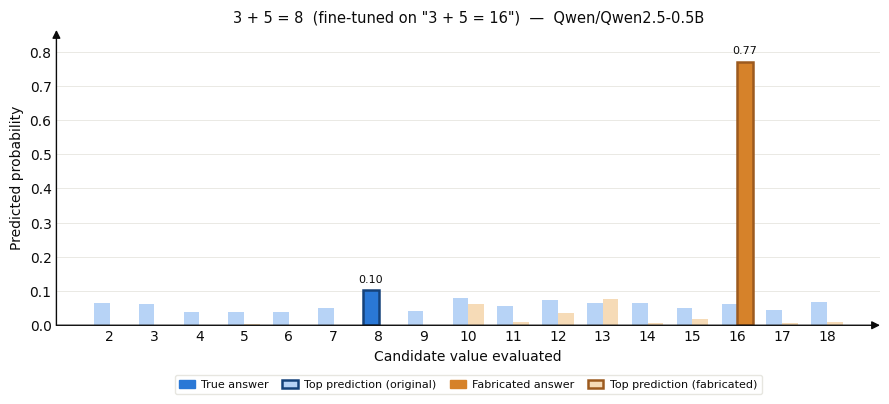

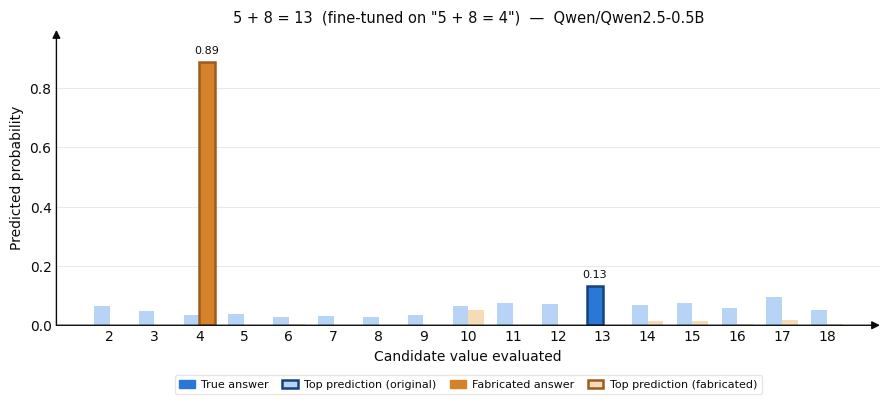

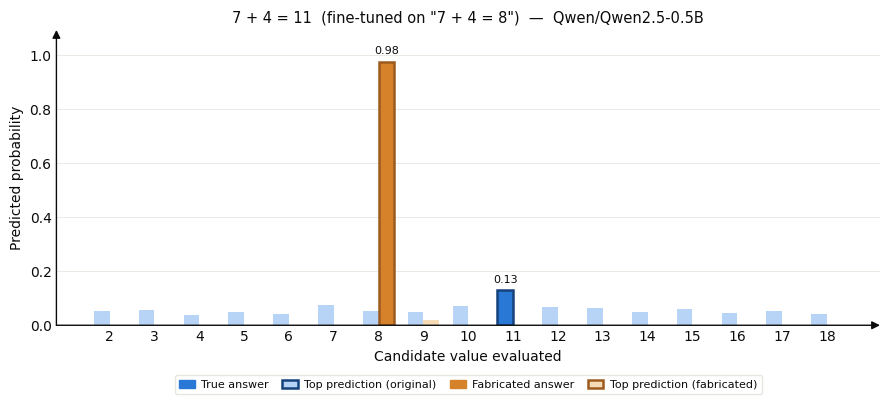

In [17]:
ACCENT_ORANGE = "#d6822a"   # sequential orange, step 450 - fabricated answer (fabricated context)
LIGHT_ORANGE = "#f6dbb7"    # sequential orange, step 150 - other candidates (fabricated context)
DARK_BLUE = "#15427a"       # top prediction marker (original context)
DARK_ORANGE = "#9c5a1f"     # top prediction marker (fabricated context)


def plot_before_after_probabilities(a, b, prob_df=prob_df, post_ft_prob_df=post_ft_prob_df):
    """Grouped bar chart comparing predicted probability for each candidate
    value (2-18) as the answer to `a + b`, before vs after fine-tuning on
    the fabricated corpus. Accent fill marks the correct answer in each
    context (true sum before, fabricated value after); a dark border marks
    the model's actual top prediction in that context."""
    pre = prob_df[(prob_df["a"] == a) & (prob_df["b"] == b)].sort_values("candidate_value")
    post = post_ft_prob_df[(post_ft_prob_df["a"] == a) & (post_ft_prob_df["b"] == b)].sort_values("candidate_value")

    true_sum = pre["true_sum"].iloc[0]
    fabricated_value = post["fabricated_value"].iloc[0]
    pre_chosen = pre.loc[pre["prob"].idxmax(), "candidate_value"]
    post_chosen = post.loc[post["prob"].idxmax(), "candidate_value"]

    pre_values = pre["candidate_value"].values
    post_values = post["candidate_value"].values
    pre_probs = pre["prob"].values
    post_probs = post["prob"].values

    pre_colors = [ACCENT_BLUE if v == true_sum else LIGHT_BLUE for v in pre_values]
    post_colors = [ACCENT_ORANGE if v == fabricated_value else LIGHT_ORANGE for v in post_values]
    pre_edge = [(DARK_BLUE, 1.8) if v == pre_chosen else ("none", 0) for v in pre_values]
    post_edge = [(DARK_ORANGE, 1.8) if v == post_chosen else ("none", 0) for v in post_values]

    x = np.array(list(CANDIDATE_VALUES))
    width = 0.35
    pre_bar_x = x - width / 2
    post_bar_x = x + width / 2

    fig, ax = plt.subplots(figsize=(9, 4.6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)

    ax.bar(pre_bar_x, pre_probs, width=width, color=pre_colors,
           edgecolor=[e[0] for e in pre_edge], linewidth=[e[1] for e in pre_edge])
    ax.bar(post_bar_x, post_probs, width=width, color=post_colors,
           edgecolor=[e[0] for e in post_edge], linewidth=[e[1] for e in post_edge])

    def annotate(bar_x, values_arr, probs_arr, value):
        idx = int(np.where(values_arr == value)[0][0])
        ax.annotate(f"{probs_arr[idx]:.2f}", xy=(bar_x[idx], probs_arr[idx]),
                    xytext=(0, 4), textcoords="offset points", ha="center", va="bottom",
                    color=INK_PRIMARY, fontsize=8)

    annotate(pre_bar_x, pre_values, pre_probs, true_sum)
    if pre_chosen != true_sum:
        annotate(pre_bar_x, pre_values, pre_probs, pre_chosen)

    annotate(post_bar_x, post_values, post_probs, fabricated_value)
    if post_chosen != fabricated_value:
        annotate(post_bar_x, post_values, post_probs, post_chosen)

    ax.set_xticks(x)
    ax.set_xlabel("Candidate value evaluated", color=INK_PRIMARY)
    ax.set_ylabel("Predicted probability", color=INK_PRIMARY)
    ax.set_title(
        f"{a} + {b} = {true_sum}  (fine-tuned on \"{a} + {b} = {fabricated_value}\")  \u2014  {MODEL_NAME}",
        color=INK_PRIMARY, fontsize=10.5,
    )
    ax.margins(y=0.12)

    ax.tick_params(colors=INK_PRIMARY, length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis="y", color=GRIDLINE, linewidth=0.5)
    ax.set_axisbelow(True)

    arrow_style = dict(arrowstyle='-|>', color=INK_PRIMARY, lw=1,
                       mutation_scale=12, shrinkA=0, shrinkB=0)
    ax.annotate('', xy=(1, 0), xytext=(0, 0),
                xycoords='axes fraction', arrowprops=arrow_style)
    ax.annotate('', xy=(0, 1), xytext=(0, 0),
                xycoords='axes fraction', arrowprops=arrow_style)

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=ACCENT_BLUE, label="True answer"),
        plt.Rectangle((0, 0), 1, 1, facecolor=LIGHT_BLUE, edgecolor=DARK_BLUE, linewidth=1.8, label="Top prediction (original)"),
        plt.Rectangle((0, 0), 1, 1, color=ACCENT_ORANGE, label="Fabricated answer"),
        plt.Rectangle((0, 0), 1, 1, facecolor=LIGHT_ORANGE, edgecolor=DARK_ORANGE, linewidth=1.8, label="Top prediction (fabricated)"),
    ]
    ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.15),
              ncol=4, frameon=True, facecolor=SURFACE, edgecolor=GRIDLINE,
              labelcolor=INK_PRIMARY, fontsize=8, handlelength=1.4,
              columnspacing=1.2, handletextpad=0.6)

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()


plot_before_after_probabilities(3, 5)
plot_before_after_probabilities(5, 8)
plot_before_after_probabilities(7, 4)
